# 10 - Compare the transit graph with random network models

We want a baseline for the structural numbers from the real station graph. A clustering coefficient or path length is hard to interpret alone, so we generate four synthetic graphs with the same number of nodes and, as closely as possible, the same number of edges:

- Erdős-Rényi for random placement at the same density;
- a configuration graph for the real degree sequence;
- a size-matched preferential-attachment graph;
- a size-matched Watts-Strogatz-style ring with rewiring.

The question is: **which parts of the real network can be explained by size, density, or degree distribution, and which parts need something else such as geographic constraint?**

We load the graph from notebook 02 when possible and can rebuild it from `stop_times.txt` as a fallback. We save the model metrics, full degree distributions, small-world ratios, and three comparison figures under `outputs/nb/10_network_model_comparison/`.

Matching edge counts is a central part of this notebook. Clustering and path length both change with density, so we do not want to compare the real network with a synthetic graph that is tens of percent denser or sparser just because a generator accepts only an integer parameter.

## 1. Set up the project paths

We locate the repository, switch into it, and create the common notebook output folder. The package helper only installs missing dependencies, and the same setup can clone the project in Colab. The rest of the notebook uses the `REPO`, `DATA`, and `OUT` paths created here.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Python 3.14.5 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
Repo root: /Users/seanfourman/Desktop/israel-transit-network-resilience


## 2. Imports, output folders, and runtime controls

We load NetworkX, pandas, NumPy, and matplotlib and create this notebook's own `tables` and `figures` folders.

The main runtime choice is `PATH_SOURCE_SAMPLES = 128`: we estimate path length by running BFS from that many seeded source nodes in each graph instead of attempting all pairs on about 30,000 nodes. `CLUSTERING_EXACT_BUDGET` decides when exact clustering is cheap enough; otherwise we use `CLUSTERING_TRIALS` samples. `WS_REWIRE_P = 0.05` controls the shortcut rate, and `SEED = 42` makes generators and sampling repeatable.

In [2]:
_ensure('networkx', 'pandas', 'matplotlib', 'numpy')

import csv
import math
import random
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

SEED = 42
PATH_SOURCE_SAMPLES = 128        # BFS sources per graph for path-length statistics
CLUSTERING_TRIALS = 2000         # fallback sample size for approximate clustering
CLUSTERING_EXACT_BUDGET = 5_000_000  # sum(degree^2) below which exact clustering is affordable
WS_REWIRE_P = 0.05               # Watts-Strogatz rewiring probability
K_MIN_TAIL = 4                   # lower cut-off for the descriptive tail-exponent estimate

STAGE = OUT / '10_network_model_comparison'
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

PREV_STAGE = OUT / '02_graph_construction'

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
print('Stage output folder:', STAGE)

Stage output folder: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/10_network_model_comparison


## 3. Decide how to obtain the real graph

We search notebook 02's output folder for a GraphML/GEXF graph or an edge-list CSV. If we find one, we can skip parsing the 816 MB GTFS file. If not, we set the notebook to rebuild the graph directly from `stop_times.txt`. This cell only chooses and prints the input path; construction happens below.

In [3]:
def find_stage02_graph():
    '''Return a graph artifact saved by notebook 02, or None if stage 02 is absent.'''
    if not PREV_STAGE.exists():
        return None
    for pattern in ('**/*.graphml', '**/*.gexf'):
        for path in sorted(PREV_STAGE.glob(pattern)):
            return path
    for path in sorted(PREV_STAGE.glob('**/*.csv')):
        if 'edge' in path.name.lower():
            return path
    return None


GRAPH_SOURCE = find_stage02_graph()
if GRAPH_SOURCE is None:
    print('No artifact found in', PREV_STAGE)
    print('Falling back to rebuilding the stop graph from the raw GTFS feed.')
    print('(Run notebook 02_graph_construction first to reuse its output.)')
else:
    print('Reusing stage 02 artifact:', GRAPH_SOURCE)

Reusing stage 02 artifact: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction/tables/edges.csv


## 4. Download the large GTFS table only if needed

`stop_times.txt` is too large to keep with the rest of the project files. We check for it only when there is no graph artifact. If the file is missing on that fallback path, we download it once and keep it on disk for later runs. When the graph artifact exists, this cell does no network work.

In [4]:
STOP_TIMES = DATA / 'stop_times.txt'

if GRAPH_SOURCE is None:
    # stop_times.txt is 816MB and is not tracked in git - fetch it on demand.
    _ensure('gdown')
    import gdown
    if not STOP_TIMES.exists():
        gdown.download(id='1V_yPAWXV6mGTFGrfiosah5LngcLZnviW',
                       output=str(STOP_TIMES), quiet=False)
    print('stop_times.txt:', round(STOP_TIMES.stat().st_size / 1024**2, 1), 'MB')
else:
    print('Raw feed not needed - the graph comes from stage 02.')

Raw feed not needed - the graph comes from stage 02.


## 5. Load or rebuild the undirected station graph

The graph rule is the same one used throughout the project: stations are nodes, and two stations share an edge when they appear consecutively in a scheduled trip. Direction is dropped for this comparison, parallel occurrences are collapsed, and their scheduled frequencies are accumulated as an edge attribute.

When we rebuild from GTFS, we stream rows in trip/sequence order and only keep the previous stop for the active trip, so memory use stays small. When we load a saved edge table or graph file, we normalize node IDs and remove self-loops. We print node count, edge count, and average degree because every null model must match those targets.

In [5]:
def gtfs_rows(path):
    '''Stream a GTFS csv file row by row (never loads the whole file).'''
    with path.open('r', encoding='utf-8-sig', newline='') as handle:
        yield from csv.DictReader(handle)


def build_undirected_stop_graph(stop_times_path):
    '''Consecutive stops within a trip become an undirected weighted edge.'''
    edge_counts = Counter()
    stop_use_counts = Counter()
    previous_trip_id = None
    previous_stop_id = None
    rows_seen = 0

    for row in gtfs_rows(stop_times_path):
        rows_seen += 1
        trip_id = row['trip_id']
        stop_id = row['stop_id']
        stop_use_counts[stop_id] += 1
        if (previous_trip_id == trip_id
                and previous_stop_id is not None
                and previous_stop_id != stop_id):
            edge_counts[(previous_stop_id, stop_id)] += 1
        previous_trip_id = trip_id
        previous_stop_id = stop_id

    graph = nx.Graph()
    graph.add_nodes_from(stop_use_counts)
    for (source, target), frequency in edge_counts.items():
        if graph.has_edge(source, target):
            graph[source][target]['frequency'] += frequency
        else:
            graph.add_edge(source, target, frequency=frequency)
    print(f'stop_times rows streamed: {rows_seen:,}')
    return graph


def load_edge_list_csv(path):
    '''Load an undirected graph from a stage-02 edge-list csv with flexible column names.'''
    frame = pd.read_csv(path, dtype=str, keep_default_na=False)
    columns = {name.lower(): name for name in frame.columns}
    source_col = next((columns[c] for c in
                       ('source', 'source_stop_id', 'from_stop_id', 'from_stop', 'stop_a', 'u')
                       if c in columns), None)
    target_col = next((columns[c] for c in
                       ('target', 'target_stop_id', 'to_stop_id', 'to_stop', 'stop_b', 'v')
                       if c in columns), None)
    if source_col is None or target_col is None:
        raise ValueError(
            f'{path} does not look like an edge list (columns: {list(frame.columns)}). '
            'Re-run notebook 02_graph_construction, or delete the file so this notebook '
            'rebuilds the graph from stop_times.txt.')
    weight_col = next((columns[c] for c in ('trip_frequency', 'frequency', 'weight', 'trips', 'count')
                       if c in columns), None)
    graph = nx.Graph()
    for _, row in frame.iterrows():
        source, target = row[source_col], row[target_col]
        weight = int(float(row[weight_col])) if weight_col else 1
        if graph.has_edge(source, target):
            graph[source][target]['frequency'] += weight
        else:
            graph.add_edge(source, target, frequency=weight)
    return graph


if GRAPH_SOURCE is None:
    G = build_undirected_stop_graph(STOP_TIMES)
elif GRAPH_SOURCE.suffix == '.graphml':
    G = nx.Graph(nx.read_graphml(GRAPH_SOURCE))
elif GRAPH_SOURCE.suffix == '.gexf':
    G = nx.Graph(nx.read_gexf(GRAPH_SOURCE))
else:
    G = load_edge_list_csv(GRAPH_SOURCE)

G.remove_edges_from(nx.selfloop_edges(G))
N_REAL = G.number_of_nodes()
M_REAL = G.number_of_edges()
if N_REAL == 0 or M_REAL == 0:
    raise RuntimeError('The loaded stop graph is empty - check the stage 02 artifact or the GTFS feed.')
print(f'Real transit graph: {N_REAL:,} nodes, {M_REAL:,} undirected edges, '
      f'average degree {2 * M_REAL / N_REAL:.3f}')

Real transit graph: 30,463 nodes, 51,772 undirected edges, average degree 3.399


## 6. Measure every graph in exactly the same way

We define one measurement pipeline for the real and synthetic graphs.

- Path statistics use the largest connected component and the same number of seeded BFS sources. The mean is an estimate; the largest observed distance is only a lower bound on diameter.
- Average clustering is exact when the degree-squared work estimate is under the budget and sampled otherwise. We save the method used.
- Each result row begins with achieved nodes, edges, and ratios to the real graph, then adds degree spread, connectivity, clustering, transitivity, and sampled path measures.

Using the same helpers prevents a difference in method from being mistaken for a difference in graph structure.

In [6]:
def largest_component_subgraph(graph):
    '''Copy of the largest connected component.'''
    largest_nodes = max(nx.connected_components(graph), key=len)
    return graph.subgraph(largest_nodes).copy()


def sampled_path_statistics(graph, source_samples, seed):
    '''Approximate average shortest path and diameter from sampled BFS sources.'''
    if graph.number_of_nodes() == 0 or source_samples <= 0:
        return {'approx_average_shortest_path': None, 'approx_diameter': None}
    component = largest_component_subgraph(graph)
    rng = random.Random(seed)
    nodes = list(component.nodes)
    sources = rng.sample(nodes, min(source_samples, len(nodes)))

    distance_sum = 0
    reached_pairs = 0
    max_distance = 0
    for source in sources:
        lengths = nx.single_source_shortest_path_length(component, source)
        for target, distance in lengths.items():
            if target == source:
                continue
            distance_sum += distance
            reached_pairs += 1
            max_distance = max(max_distance, distance)
    if reached_pairs == 0:
        return {'approx_average_shortest_path': None, 'approx_diameter': None}
    return {'approx_average_shortest_path': distance_sum / reached_pairs,
            'approx_diameter': max_distance}


def average_clustering_value(graph, trials, seed):
    '''Exact average clustering when affordable, sampled estimate otherwise.'''
    cost_proxy = sum(degree * degree for _, degree in graph.degree())
    if cost_proxy <= CLUSTERING_EXACT_BUDGET:
        return nx.average_clustering(graph), 'exact'
    sampled = nx.algorithms.approximation.average_clustering(
        graph, trials=min(trials, graph.number_of_nodes()), seed=seed)
    return sampled, f'sampled_{trials}'


def graph_property_row(name, graph, seed=SEED):
    '''One row of the model-comparison table, sizes first so mismatches are visible.'''
    n = graph.number_of_nodes()
    m = graph.number_of_edges()
    degrees = [degree for _, degree in graph.degree()]
    component_sizes = sorted((len(c) for c in nx.connected_components(graph)), reverse=True)
    path_stats = sampled_path_statistics(graph, PATH_SOURCE_SAMPLES, seed)
    clustering, clustering_method = average_clustering_value(graph, CLUSTERING_TRIALS, seed)
    return {
        'model': name,
        'nodes': n,
        'edges': m,
        'node_ratio_vs_real': n / N_REAL,
        'edge_ratio_vs_real': m / M_REAL,
        'average_degree': 2 * m / n if n else 0.0,
        'max_degree': max(degrees) if degrees else 0,
        'degree_std': float(np.std(degrees)) if degrees else 0.0,
        'density': nx.density(graph) if n > 1 else 0.0,
        'connected_components': len(component_sizes),
        'largest_component_share': component_sizes[0] / n if n else 0.0,
        'average_clustering': clustering,
        'clustering_method': clustering_method,
        'transitivity': nx.transitivity(graph),
        'approx_average_shortest_path': path_stats['approx_average_shortest_path'],
        'approx_diameter': path_stats['approx_diameter'],
    }


print('Measurement helpers ready.')

Measurement helpers ready.


## 7. Define four null-model generators

Each generator controls for a different part of the real graph:

| model | what we keep or impose |
| --- | --- |
| Erdős-Rényi `G(n,m)` | node count and exact edge count |
| configuration graph | the real degree sequence, then simplify loops and parallel edges |
| preferential attachment | degree-proportional attachment with an exact total edge budget |
| rewired ring | a local ring/chord lattice with an exact edge budget and 5% rewiring |

The last two need custom size matching because their classic NetworkX parameters are integers while the real mean degree is about 3.4. For preferential attachment we alternate one or two attachments so cumulative edges track the target. For the ring model we add local chords until the target is reached and then rewire without changing the total.

The simplified configuration graph can lose a few edges when self-loops and parallel edges are removed. We leave that loss visible because adding replacements would stop it from preserving the sampled degree sequence.

In [7]:
def simple_configuration_graph(degree_sequence, seed):
    '''Configuration model, then collapse parallel edges and drop self-loops.

    Keeps the real degree sequence exactly up to the collapse; the resulting
    (slightly smaller) edge count is reported in the comparison table.
    '''
    multigraph = nx.configuration_model(degree_sequence, seed=seed)
    graph = nx.Graph(multigraph)
    graph.remove_edges_from(nx.selfloop_edges(graph))
    return graph


def _random_subset(repeated_nodes, k, rng):
    '''Pick k distinct nodes with probability proportional to degree.

    `repeated_nodes` contains each node once per incident edge, so a uniform
    draw from it is a degree-proportional draw - the standard preferential
    attachment trick used by networkx itself.
    '''
    targets = set()
    while len(targets) < k:
        targets.add(rng.choice(repeated_nodes))
    return targets


def size_matched_barabasi_albert(n, m_target, seed):
    '''Preferential attachment with a fractional attachment parameter.

    Textbook BA adds an integer number of edges per new node and therefore
    cannot hit a target of m/n = 1.7 edges per node. Here the number of edges
    added by each new node is chosen from the remaining edge budget, so the
    final graph has exactly m_target edges while attachment remains
    degree-proportional.
    '''
    rng = random.Random(seed)
    m_start = max(1, int(math.ceil(m_target / n)))
    graph = nx.empty_graph(m_start)
    repeated_nodes = list(range(m_start))
    for new_node in range(m_start, n):
        remaining_nodes = n - new_node
        needed = m_target - graph.number_of_edges()
        k = int(round(needed / remaining_nodes)) if remaining_nodes else 1
        k = max(1, min(k, new_node))
        targets = _random_subset(repeated_nodes, k, rng)
        graph.add_node(new_node)
        for target in targets:
            graph.add_edge(new_node, target)
        repeated_nodes.extend(targets)
        repeated_nodes.extend([new_node] * k)
    return graph


def size_matched_watts_strogatz(n, m_target, rewire_p, seed):
    '''Watts-Strogatz style small world with an exact edge budget.

    Step 1: ring lattice of nearest neighbours (n edges).
    Step 2: add chords at distance 2, 3, ... to a random subset of nodes until
            the edge budget is met exactly (this is what allows a non-even
            effective k, i.e. an average degree of 3.4 rather than 2 or 4).
    Step 3: rewire each edge with probability rewire_p by moving one endpoint
            to a random node - this creates the shortcuts that give the small
            world its short paths and never changes the edge count.
    '''
    rng = random.Random(seed)
    graph = nx.Graph()
    graph.add_nodes_from(range(n))
    for i in range(n):
        graph.add_edge(i, (i + 1) % n)

    distance = 2
    while graph.number_of_edges() < m_target and distance < n // 2:
        order = list(range(n))
        rng.shuffle(order)
        for i in order:
            if graph.number_of_edges() >= m_target:
                break
            j = (i + distance) % n
            if i != j and not graph.has_edge(i, j):
                graph.add_edge(i, j)
        distance += 1

    if graph.number_of_edges() > m_target:
        surplus = graph.number_of_edges() - m_target
        edges = list(graph.edges())
        rng.shuffle(edges)
        graph.remove_edges_from(edges[:surplus])

    for u, v in list(graph.edges()):
        if rng.random() >= rewire_p:
            continue
        for _ in range(32):
            w = rng.randrange(n)
            if w != u and not graph.has_edge(u, w):
                graph.remove_edge(u, v)
                graph.add_edge(u, w)
                break
    return graph


print('Model generators ready.')

Model generators ready.


## 8. Generate the models and check their sizes

We build all four graphs with the same seeded random generator and print their achieved `n` and `m` beside the real targets. We also calculate the edge counts that simple rounded integer settings would produce for the attachment and ring models. Those extra values are only a density diagnostic: they show why the exact-edge-budget versions are needed before we compare clustering or paths.

In [8]:
degree_sequence = [degree for _, degree in G.degree()]

models = {}
models['real_transit'] = G
print('Building Erdős-Rényi null model ...', flush=True)
models['erdos_renyi_gnm'] = nx.gnm_random_graph(N_REAL, M_REAL, seed=SEED)
print('Building configuration-model null model ...', flush=True)
models['configuration_degree_sequence'] = simple_configuration_graph(degree_sequence, SEED)
print('Building size-matched Barabási-Albert null model ...', flush=True)
models['barabasi_albert_matched'] = size_matched_barabasi_albert(N_REAL, M_REAL, SEED)
print('Building size-matched Watts-Strogatz null model (the slowest one) ...', flush=True)
models['watts_strogatz_matched'] = size_matched_watts_strogatz(N_REAL, M_REAL, WS_REWIRE_P, SEED)

print('Achieved sizes')
for name, graph in models.items():
    n_model = graph.number_of_nodes()
    m_model = graph.number_of_edges()
    print(f'  {name:32s} n={n_model:7,d}  m={m_model:7,d}  edges vs real = {m_model / M_REAL:6.1%}')

# Direct rounded-parameter formulas show why we need the explicit size-matching search.
ROUNDED_BA_M = max(1, int(round(M_REAL / N_REAL)))
ROUNDED_BA_EDGES = ROUNDED_BA_M * (N_REAL - ROUNDED_BA_M)
ROUNDED_WS_RAW_K = max(2, int(round(2 * M_REAL / N_REAL)))
ROUNDED_WS_K = ROUNDED_WS_RAW_K if ROUNDED_WS_RAW_K % 2 == 0 else ROUNDED_WS_RAW_K - 1
ROUNDED_WS_EDGES = N_REAL * ROUNDED_WS_K // 2
print()
print('Rounded-parameter check (not size-matched)')
print(f'  barabasi_albert m=round(m/n)={ROUNDED_BA_M} would give about {ROUNDED_BA_EDGES:,} edges '
      f'({ROUNDED_BA_EDGES / M_REAL:.1%} of the real network)')
print(f'  watts_strogatz forced-even k={ROUNDED_WS_K} would give exactly {ROUNDED_WS_EDGES:,} edges '
      f'({ROUNDED_WS_EDGES / M_REAL:.1%} of the real network)')

Building Erdős-Rényi null model ...
Building configuration-model null model ...
Building size-matched Barabási-Albert null model ...
Building size-matched Watts-Strogatz null model (the slowest one) ...
Achieved sizes
  real_transit                     n= 30,463  m= 51,772  edges vs real = 100.0%
  erdos_renyi_gnm                  n= 30,463  m= 51,772  edges vs real = 100.0%
  configuration_degree_sequence    n= 30,463  m= 51,768  edges vs real = 100.0%
  barabasi_albert_matched          n= 30,463  m= 51,772  edges vs real = 100.0%
  watts_strogatz_matched           n= 30,463  m= 51,772  edges vs real = 100.0%

Rounded-parameter check (not size-matched)
  barabasi_albert m=round(m/n)=2 would give about 60,922 edges (117.7% of the real network)
  watts_strogatz forced-even k=2 would give exactly 30,463 edges (58.8% of the real network)


## 9. Build the main comparison table

We pass the real graph and every model through `graph_property_row` and save the resulting table. This is the most expensive cell because it performs 128 BFS runs per graph plus clustering and transitivity.

We keep both average local clustering and transitivity. Average clustering weights each node's neighborhood equally, while transitivity weights high-degree nodes more heavily through the global triangle-to-wedge ratio. Their disagreement can be informative in a heterogeneous network.

In [9]:
property_rows = []
for name, graph in models.items():
    print(f'Measuring {name} ...', flush=True)
    property_rows.append(graph_property_row(name, graph))
comparison = pd.DataFrame(property_rows)
comparison.to_csv(TABLES / 'network_model_comparison.csv', index=False, encoding='utf-8-sig')
print('Written:', TABLES / 'network_model_comparison.csv')
comparison.round(4)

Measuring real_transit ...
Measuring erdos_renyi_gnm ...
Measuring configuration_degree_sequence ...
Measuring barabasi_albert_matched ...
Measuring watts_strogatz_matched ...
Written: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/10_network_model_comparison/tables/network_model_comparison.csv


,model,nodes,edges,node_ratio_vs_real,edge_ratio_vs_real,average_degree,max_degree,degree_std,density,connected_components,largest_component_share,average_clustering,clustering_method,transitivity,approx_average_shortest_path,approx_diameter
0,real_transit,30463,51772,1.0,1.0000,3.3990,62,2.1967,0.0001,12,0.9926,0.0968,exact,0.1113,13.8447,56
1,erdos_renyi_gnm,30463,51772,1.0,1.0000,3.3990,14,1.8442,0.0001,1075,0.9628,0.0000,exact,0.0001,8.5296,17
2,configuration_degree_sequence,30463,51768,1.0,0.9999,3.3987,62,2.1962,0.0001,4,0.9998,0.0001,exact,0.0001,8.1433,17
3,barabasi_albert_matched,30463,51772,1.0,1.0000,3.3990,452,6.4099,0.0001,1,1.0000,0.0016,exact,0.0006,5.7539,11
4,watts_strogatz_matched,30463,51772,1.0,1.0000,3.3990,7,0.7479,0.0001,1,1.0000,0.4495,exact,0.4132,25.3638,54


## 10. Compare the full degree distributions

For each graph we calculate `P(k)` and the complementary cumulative distribution `P(K >= k)`, then save both the long-form curves and a summary table.

The summary includes mean, standard deviation, maximum degree, share with degree at least ten, isolated nodes, and KS distance from the real empirical degree distribution. We also calculate a Hill-style tail exponent above fixed `k = 4`, but we use it only as a rough description of tail heaviness. A fixed cutoff without a goodness-of-fit test is not evidence that the graph follows a power law.

In [10]:
def degree_distribution_frame(name, graph):
    '''Long-form degree distribution: P(k), CDF and CCDF for one graph.'''
    counts = Counter(degree for _, degree in graph.degree())
    n = graph.number_of_nodes()
    rows = []
    cumulative = 0
    for degree in sorted(counts):
        nodes = counts[degree]
        cumulative += nodes
        rows.append({'model': name, 'degree': degree, 'nodes': nodes,
                     'probability': nodes / n if n else 0.0,
                     'cumulative_probability': cumulative / n if n else 0.0,
                     'ccdf': 1.0 - (cumulative - nodes) / n if n else 0.0})
    return pd.DataFrame(rows)


def degree_cdf(degrees, max_k):
    counts = np.bincount(np.asarray(degrees, dtype=int), minlength=max_k + 1)
    return np.cumsum(counts) / counts.sum()


def ks_statistic(degrees_a, degrees_b):
    '''Kolmogorov-Smirnov distance between two empirical degree distributions.'''
    max_k = max(max(degrees_a), max(degrees_b))
    return float(np.max(np.abs(degree_cdf(degrees_a, max_k) - degree_cdf(degrees_b, max_k))))


def hill_alpha(degrees, k_min):
    '''MLE power-law exponent for the tail k >= k_min. Descriptive only.'''
    tail = [d for d in degrees if d >= k_min]
    if len(tail) < 20:
        return None
    total = sum(math.log(d / (k_min - 0.5)) for d in tail)
    if total <= 0:
        return None
    return 1.0 + len(tail) / total


distributions = pd.concat(
    [degree_distribution_frame(name, graph) for name, graph in models.items()],
    ignore_index=True)
distributions.to_csv(TABLES / 'degree_distributions.csv', index=False, encoding='utf-8-sig')

real_degrees = [degree for _, degree in G.degree()]
summary_rows = []
for name, graph in models.items():
    degrees = [degree for _, degree in graph.degree()]
    array = np.asarray(degrees)
    summary_rows.append({
        'model': name,
        'nodes': graph.number_of_nodes(),
        'edges': graph.number_of_edges(),
        'mean_degree': float(array.mean()),
        'std_degree': float(array.std()),
        'max_degree': int(array.max()),
        'share_degree_ge_10': float((array >= 10).mean()),
        'isolated_nodes': int((array == 0).sum()),
        'hill_alpha_kmin4': hill_alpha(degrees, K_MIN_TAIL),
        'ks_vs_real': 0.0 if name == 'real_transit' else ks_statistic(degrees, real_degrees),
    })

degree_summary = pd.DataFrame(summary_rows)
degree_summary.to_csv(TABLES / 'degree_distribution_summary.csv', index=False, encoding='utf-8-sig')
print('Written:', TABLES / 'degree_distributions.csv')
print('Written:', TABLES / 'degree_distribution_summary.csv')
degree_summary.round(4)

Written: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/10_network_model_comparison/tables/degree_distributions.csv
Written: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/10_network_model_comparison/tables/degree_distribution_summary.csv


,model,nodes,edges,mean_degree,std_degree,max_degree,share_degree_ge_10,isolated_nodes,hill_alpha_kmin4,ks_vs_real
0,real_transit,30463,51772,3.3990,2.1967,62,0.0202,0,3.4601,0.0000
1,erdos_renyi_gnm,30463,51772,3.3990,1.8442,14,0.0023,1021,3.8730,0.1298
2,configuration_degree_sequence,30463,51768,3.3987,2.1962,62,0.0202,0,3.4608,0.0001
3,barabasi_albert_matched,30463,51772,3.3990,6.4099,452,0.0462,0,2.6352,0.2404
4,watts_strogatz_matched,30463,51772,3.3990,0.7479,7,0.0000,0,7.6517,0.3344


## 11. Plot degree probability and the CCDF

The left panel shows `P(k)` on log-log axes; the right shows `P(K >= k)`. The raw probability becomes noisy in the high-degree tail, while the CCDF is smoother and makes the cutoff shape easier to compare. We use the model curves to see whether the real graph looks narrow like a ring/random graph, extremely hub-heavy like preferential attachment, or closest to its degree-preserving configuration baseline.

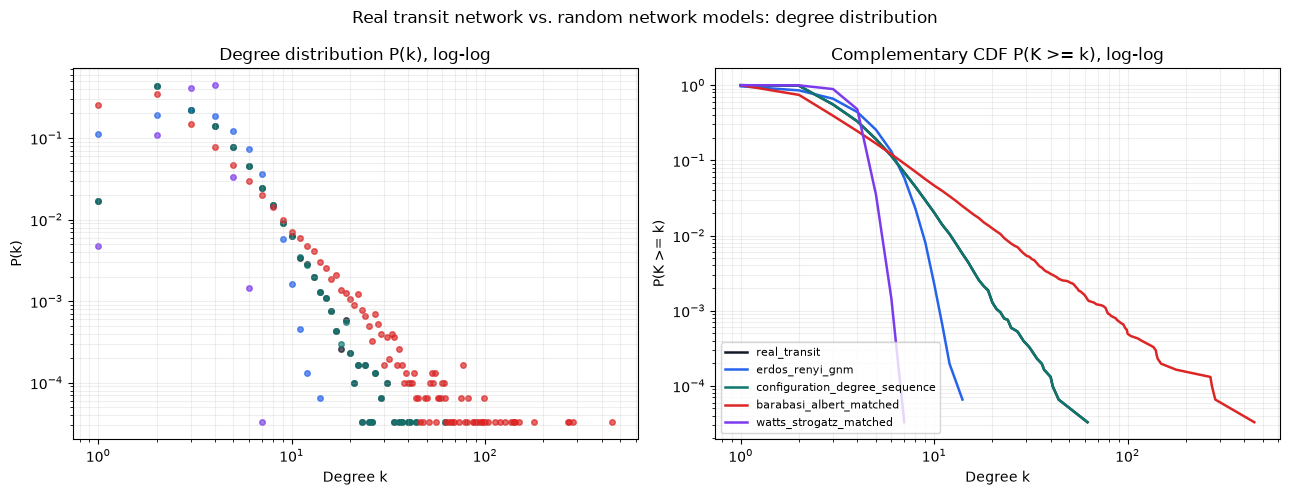

Written: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/10_network_model_comparison/figures/degree_distribution_comparison.png


In [11]:
PALETTE = {
    'real_transit': '#111827',
    'erdos_renyi_gnm': '#2563eb',
    'configuration_degree_sequence': '#0f766e',
    'barabasi_albert_matched': '#dc2626',
    'watts_strogatz_matched': '#7c3aed',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in models:
    subset = distributions[(distributions['model'] == name) & (distributions['degree'] > 0)]
    colour = PALETTE.get(name, '#6b7280')
    axes[0].scatter(subset['degree'], subset['probability'], s=16, alpha=0.7,
                    color=colour, label=name)
    axes[1].plot(subset['degree'], subset['ccdf'].clip(lower=1e-6),
                 linewidth=1.8, color=colour, label=name)

axes[0].set_title('Degree distribution P(k), log-log')
axes[0].set_ylabel('P(k)')
axes[1].set_title('Complementary CDF P(K >= k), log-log')
axes[1].set_ylabel('P(K >= k)')
for ax in axes:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Degree k')
    ax.grid(True, which='both', alpha=0.2)
axes[1].legend(fontsize=8, loc='lower left')
fig.suptitle('Real transit network vs. random network models: degree distribution')
fig.tight_layout()
fig.savefig(FIGURES / 'degree_distribution_comparison.png', dpi=180)
plt.show()
print('Written:', FIGURES / 'degree_distribution_comparison.png')

## 12. Compare clustering, transitivity, and path length

We put the three central structural measures in separate panels because they have very different scales. Since the generators are now matched on node and edge counts, large differences are less likely to be a trivial density effect. The labels show the actual numerical value over each bar so a near-zero random baseline remains visible.

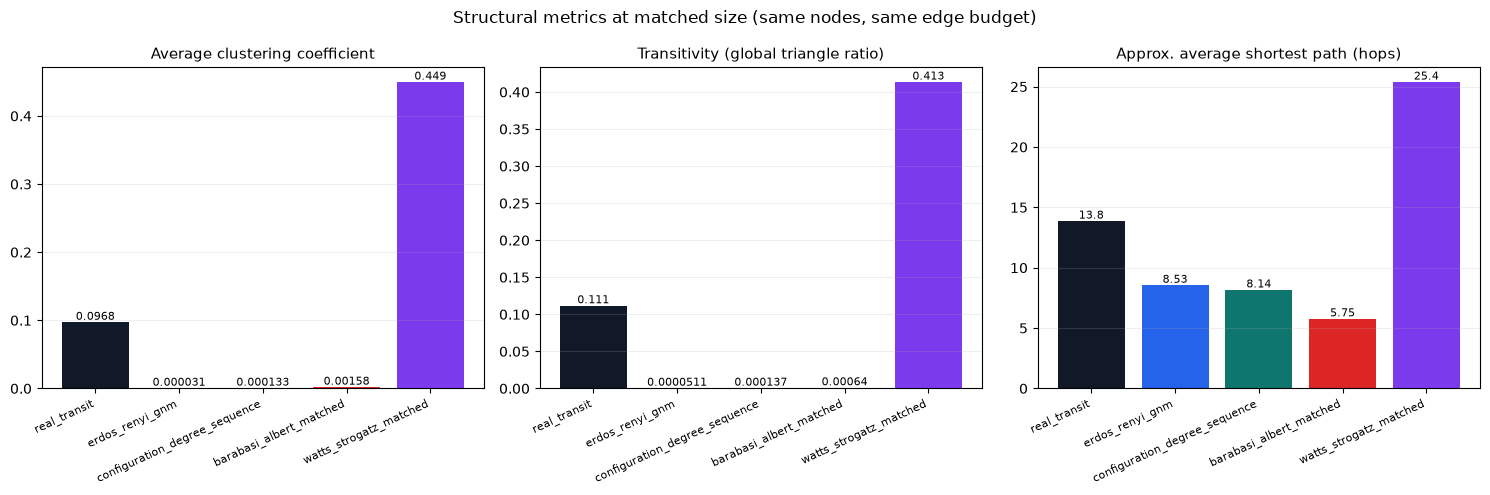

Written: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/10_network_model_comparison/figures/model_metric_comparison.png


In [12]:
def _plain(v, sig=3):
    """Format a number as a plain decimal with `sig` significant figures - never 1e-4 style."""
    import math
    v = float(v)
    if not math.isfinite(v) or v == 0:
        return '0'
    d = max(0, sig - 1 - int(math.floor(math.log10(abs(v)))))
    s = f'{v:.{d}f}'
    return s.rstrip('0').rstrip('.') if '.' in s else s


metric_specs = [
    ('average_clustering', 'Average clustering coefficient'),
    ('transitivity', 'Transitivity (global triangle ratio)'),
    ('approx_average_shortest_path', 'Approx. average shortest path (hops)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
labels = comparison['model'].tolist()
colours = [PALETTE.get(name, '#6b7280') for name in labels]
for ax, (column, title) in zip(axes, metric_specs):
    values = pd.to_numeric(comparison[column], errors='coerce').fillna(0.0)
    ax.bar(range(len(labels)), values, color=colours)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.grid(True, axis='y', alpha=0.2)
    for x, value in enumerate(values):
        ax.annotate(_plain(value), (x, value), ha='center', va='bottom', fontsize=8)

fig.suptitle('Structural metrics at matched size (same nodes, same edge budget)')
fig.tight_layout()
fig.savefig(FIGURES / 'model_metric_comparison.png', dpi=180)
plt.show()
print('Written:', FIGURES / 'model_metric_comparison.png')

## 13. Keep a visible size-match check

This figure plots each achieved edge count against the real graph's edge count. We include the simple rounded-parameter attachment and ring counts in gray as reference cases. The point is to make any density mismatch obvious before we interpret the structural comparison. In the actual model set, only the simplified configuration graph should miss by a few collapsed edges.

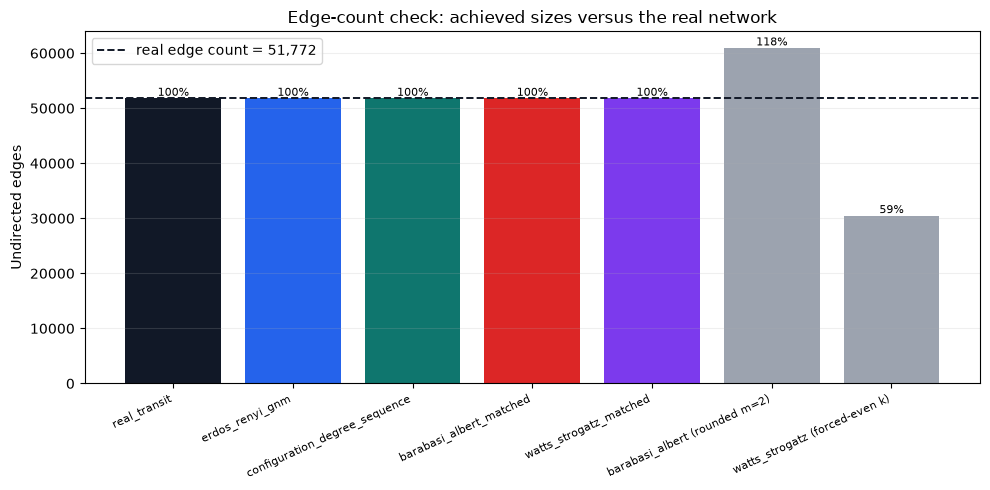

Written: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/10_network_model_comparison/figures/size_match_check.png


In [13]:
check_labels = list(models.keys()) + ['barabasi_albert (rounded m=2)', 'watts_strogatz (forced-even k)']
check_values = [graph.number_of_edges() for graph in models.values()] + [ROUNDED_BA_EDGES, ROUNDED_WS_EDGES]
check_colours = [PALETTE.get(name, '#6b7280') for name in models] + ['#9ca3af', '#9ca3af']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(check_labels)), check_values, color=check_colours)
ax.axhline(M_REAL, color='#111827', linestyle='--', linewidth=1.4,
           label=f'real edge count = {M_REAL:,}')
ax.set_xticks(range(len(check_labels)))
ax.set_xticklabels(check_labels, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('Undirected edges')
ax.set_title('Edge-count check: achieved sizes versus the real network')
ax.grid(True, axis='y', alpha=0.2)
for x, value in enumerate(check_values):
    ax.annotate(f'{value / M_REAL:.0%}', (x, value), ha='center', va='bottom', fontsize=8)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'size_match_check.png', dpi=180)
plt.show()
print('Written:', FIGURES / 'size_match_check.png')

## 14. Calculate small-world ratios carefully

We use Erdős-Rényi as the same-size random reference and calculate:

$$C/C_{rand}, \qquad L/L_{rand}, \qquad
\sigma = \frac{C/C_{rand}}{L/L_{rand}}.$$

`sigma > 1` is often used as a small-world signal, but here `C_rand` is extremely close to zero, so the ratio can become enormous from a tiny denominator. We therefore look at `C/C_rand` and `L/L_rand` separately. The path values are also sample estimates, not exact all-pairs results.

In [14]:
def safe_ratio(numerator, denominator):
    if numerator is None or denominator is None:
        return None
    try:
        if float(denominator) == 0.0:
            return None
        return float(numerator) / float(denominator)
    except (TypeError, ValueError):
        return None


indexed = comparison.set_index('model')
reference = indexed.loc['erdos_renyi_gnm']
c_random = reference['average_clustering']
l_random = reference['approx_average_shortest_path']

small_world_rows = []
for name in indexed.index:
    row = indexed.loc[name]
    c_ratio = safe_ratio(row['average_clustering'], c_random)
    l_ratio = safe_ratio(row['approx_average_shortest_path'], l_random)
    small_world_rows.append({
        'model': name,
        'clustering_C': row['average_clustering'],
        'avg_path_L': row['approx_average_shortest_path'],
        'C_over_C_random': c_ratio,
        'L_over_L_random': l_ratio,
        'small_world_sigma': safe_ratio(c_ratio, l_ratio),
    })

small_world = pd.DataFrame(small_world_rows)
small_world.to_csv(TABLES / 'small_world_ratios.csv', index=False, encoding='utf-8-sig')
print('Written:', TABLES / 'small_world_ratios.csv')
small_world.round(3)

Written: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/10_network_model_comparison/tables/small_world_ratios.csv


,model,clustering_C,avg_path_L,C_over_C_random,L_over_L_random,small_world_sigma
0,real_transit,0.097,13.845,3122.917,1.623,1923.995
1,erdos_renyi_gnm,0.000,8.530,1.000,1.000,1.000
2,configuration_degree_sequence,0.000,8.143,4.303,0.955,4.507
3,barabasi_albert_matched,0.002,5.754,51.012,0.675,75.619
4,watts_strogatz_matched,0.449,25.364,14497.760,2.974,4875.445


## 15. Print the result directly from the tables

We finish the numerical part by printing achieved size, the degree-distribution KS distances, real-versus-random clustering and path length, and the saved file locations. Building this text from the current DataFrames keeps the stated verdict tied to the actual run instead of to numbers typed by hand.

In [15]:
def fmt(value, digits=4):
    if value is None:
        return 'n/a'
    try:
        number = float(value)
    except (TypeError, ValueError):
        return str(value)
    if math.isnan(number):
        return 'n/a'
    return f'{number:.{digits}f}'


real_row = indexed.loc['real_transit']
ks_ranking = degree_summary[degree_summary['model'] != 'real_transit'].sort_values('ks_vs_real')
best_degree_model = ks_ranking.iloc[0]
sw_indexed = small_world.set_index('model')
real_sw = sw_indexed.loc['real_transit']

print('=== Size match ===')
for name in indexed.index:
    ratio = indexed.loc[name, 'edge_ratio_vs_real']
    node_ratio = indexed.loc[name, 'node_ratio_vs_real']
    print(f'  {name:32s} nodes {node_ratio:6.1%}   edges {ratio:6.1%}')

print()
print('=== Degree distribution ===')
for _, row in degree_summary.iterrows():
    print(f'  {row["model"]:32s} mean {row["mean_degree"]:5.2f}  std {row["std_degree"]:5.2f}  '
          f'max {int(row["max_degree"]):4d}  KS vs real {row["ks_vs_real"]:.4f}')
print(f'  Closest degree distribution to the real graph: {best_degree_model["model"]} '
      f'(KS = {best_degree_model["ks_vs_real"]:.4f})')

print()
print('=== Clustering and path length ===')
print(f'  real   C = {fmt(real_row["average_clustering"])}   L = {fmt(real_row["approx_average_shortest_path"], 2)}')
print(f'  random C = {fmt(c_random)}   L = {fmt(l_random, 2)}')
print(f'  real C / random C = {fmt(real_sw["C_over_C_random"], 1)}   '
      f'real L / random L = {fmt(real_sw["L_over_L_random"], 2)}   '
      f'sigma = {fmt(real_sw["small_world_sigma"], 1)}')

l_ratio_value = real_sw['L_over_L_random']
# A Watts-Strogatz small world needs BOTH high clustering AND near-random path lengths
# (L / L_random close to 1). Here paths are markedly longer than random, so despite the
# high clustering the network is not a small world in the WS sense - matching Conclusion 3.
if l_ratio_value is not None and float(l_ratio_value) > 1.5:
    print('  -> The real network is far MORE clustered than random but its paths are also much '
          f'longer than random (L / L_random = {fmt(l_ratio_value, 2)}): it is not a small '
          'world in the Watts-Strogatz sense.')
else:
    print('  -> The real network combines above-random clustering with near-random path lengths: '
          'small-world behaviour.')

print()
print('=== Stage outputs ===')
for path in sorted(TABLES.glob('*.csv')) + sorted(FIGURES.glob('*.png')):
    print(' ', path.relative_to(REPO))

=== Size match ===
  real_transit                     nodes 100.0%   edges 100.0%
  erdos_renyi_gnm                  nodes 100.0%   edges 100.0%
  configuration_degree_sequence    nodes 100.0%   edges 100.0%
  barabasi_albert_matched          nodes 100.0%   edges 100.0%
  watts_strogatz_matched           nodes 100.0%   edges 100.0%

=== Degree distribution ===
  real_transit                     mean  3.40  std  2.20  max   62  KS vs real 0.0000
  erdos_renyi_gnm                  mean  3.40  std  1.84  max   14  KS vs real 0.1298
  configuration_degree_sequence    mean  3.40  std  2.20  max   62  KS vs real 0.0001
  barabasi_albert_matched          mean  3.40  std  6.41  max  452  KS vs real 0.2404
  watts_strogatz_matched           mean  3.40  std  0.75  max    7  KS vs real 0.3344
  Closest degree distribution to the real graph: configuration_degree_sequence (KS = 0.0001)

=== Clustering and path length ===
  real   C = 0.0968   L = 13.84
  random C = 0.0000   L = 8.53
  real C / rand

## Conclusions

1. **The comparison is genuinely size matched.** The real graph has 30,463 nodes and 51,772 edges. Erdős-Rényi, preferential attachment, and the rewired-ring model hit both counts exactly; the simplified configuration graph loses only four edges. This means the large metric differences are not being caused by a 20-40% density gap.

2. **The degree sequence explains degrees, but not triangles.** The configuration model has KS distance `0.0001` from the real degree distribution and matches its maximum degree of 62, yet its average clustering is only `0.0001` compared with `0.0968` in the real graph. The real clustering is therefore not just a side effect of having that degree sequence.

3. **None of the other simple mechanisms matches the whole graph.** Erdős-Rényi has a narrower degree distribution, maximum degree 14, and almost no clustering. Preferential attachment overshoots the tail badly (maximum degree 452 and KS `0.2404`) and gives very short sampled paths of 5.75 hops. The rewired ring creates much more clustering (`0.4495`) but degrees are too uniform (maximum 7, KS `0.3344`) and paths are much longer at 25.36 hops.

4. **The real network sits between the random and lattice extremes.** Its sampled mean shortest path is 13.84 hops, compared with 8.53 for Erdős-Rényi and 25.36 for the rewired ring. Its clustering is about 3,123 times the random value, while its path length is 1.62 times the random value. The very large `sigma` is driven mainly by an almost-zero random clustering denominator, so we do not use that number alone as proof of a small world.

5. **Geography is the most plausible missing mechanism, but this notebook does not test space directly.** Transit edges follow roads, tracks, and service corridors, which naturally create local clustering and longer national paths. A spatial null model would be the next useful comparison. For now, the safe conclusion is simply that density, degree sequence, preferential attachment, and a one-dimensional rewired lattice each fail to reproduce the observed combination.

The path length and diameter are based on 128 BFS sources, and the diameter is a lower bound. The fixed-cutoff tail exponent is descriptive only. We should rerun with more sources if a small difference in path length ever becomes central to the argument.